# Uniform Probability Distribution

## 1. Definition

## 2. Intuition


## 3. Parameter

## 4. Support

## 5. Probability Mass Function


## 6. Cumulative Distribution Function


## 7. Moments

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf, gammainc, gammaln, betainc, betaln


def validate_sample_size(size):
    if not isinstance(size, (int, np.integer)):
        raise TypeError("size must be an integer.")

    if size < 1:
        raise ValueError("size must be at least 1.")

In [2]:
class Uniform:
    """
    Continuous uniform distribution over [a, b].
    """

    def __init__(self, a: float, b: float):
        if not np.isfinite(a) or not np.isfinite(b):
            raise ValueError("a and b must be finite.")

        if a >= b:
            raise ValueError("a must be smaller than b.")

        self.a = float(a)
        self.b = float(b)

    def pdf(self, x):
        x = np.asarray(x)

        density = np.zeros_like(x, dtype=float)

        valid = (x >= self.a) & (x <= self.b)
        density[valid] = 1.0 / (self.b - self.a)

        return density

    def cdf(self, x):
        x = np.asarray(x)

        probability = np.zeros_like(x, dtype=float)

        probability[x >= self.b] = 1.0

        valid = (x > self.a) & (x < self.b)

        probability[valid] = (
            (x[valid] - self.a)
            / (self.b - self.a)
        )

        return probability

    def mean(self):
        return 0.5 * (self.a + self.b)

    def variance(self):
        return (self.b - self.a) ** 2 / 12

    def sample(self, size=1, random_state=None):
        validate_sample_size(size)

        rng = np.random.default_rng(random_state)

        # Inverse-transform sampling
        u = rng.random(size)

        return self.a + (self.b - self.a) * u

    def plot(self, num_points=500, figsize=(10, 4)):
        margin = 0.2 * (self.b - self.a)

        x = np.linspace(
            self.a - margin,
            self.b + margin,
            num_points,
        )

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].plot(x, self.pdf(x))
        axes[0].set_title("Uniform PDF")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Density")
        axes[0].grid(True)

        axes[1].plot(x, self.cdf(x))
        axes[1].set_title("Uniform CDF")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("Cumulative probability")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

Uniform mean: 1.0
Uniform samples: [ 2.64373629  0.63327064  3.15158752  2.18420817 -1.43493591]


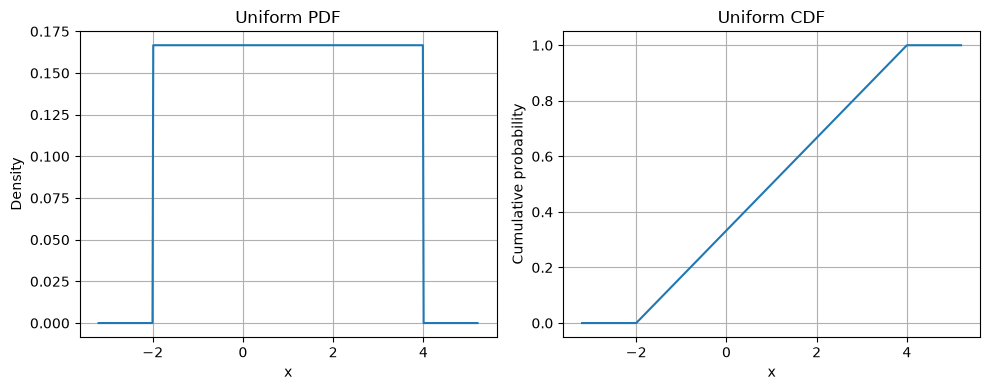

In [3]:
uniform = Uniform(a=-2, b=4)
print("Uniform mean:", uniform.mean())
print("Uniform samples:", uniform.sample(5, random_state=42))
uniform.plot()